# 02 Domain Shift: Hybrid Vs Paired

This notebook shows why naive transfer was never going to be enough. The central question is not whether the model is powerful, but whether the source and target domains are even close enough for direct transfer to work.

**Questions answered here**
- How separable are hybrid and paired units?
- Does context make prediction easier while also making domains more separable?
- Which feature groups carry the strongest hybrid-to-paired shift?


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

def _find_thesis_root():
    cwd = Path.cwd().resolve()
    direct = [cwd, *cwd.parents]
    nested = [candidate / "thesis" for candidate in direct]
    for candidate in [*direct, *nested]:
        if (candidate / "THESIS_BLUEPRINT.md").exists() and (candidate / "src" / "qc_thesis" / "__init__.py").exists():
            return candidate
    raise FileNotFoundError("Could not find thesis root from notebook session")

ROOT = _find_thesis_root()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from qc_thesis import *

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
apply_thesis_style()

fig_dir, table_dir = notebook_output_dirs("02_domain_shift_hybrid_vs_paired")
live_bundle = get_domain_shift_bundle()
frozen_domain_summary = pd.read_csv(ROOT / "data/frozen_inputs/domain_shift/domain_classifier_summary.csv")
frozen_feature_group = pd.read_csv(ROOT / "data/frozen_inputs/domain_shift/feature_group_summary.csv")


## 1. Domain separability

The benchmark result that matters here is simple: if a lightweight classifier can tell hybrid from paired almost perfectly, then naive transfer is structurally unsafe. Context usually helps the prediction task, but it also increases domain identifiability.


,comparison,feature_set,rows_a,rows_b,n_features,cv_auc_mean,cv_auc_std
0,hybrid_vs_paired_all,unit,5000,5000,164,0.976470,0.046301
1,hybrid_vs_paired_all,full_context,5000,5000,685,0.999738,0.000524
2,hybrid_vs_paired_test,unit,5000,100,164,0.999653,0.000694
3,hybrid_vs_paired_test,full_context,5000,100,685,1.000000,0.000000


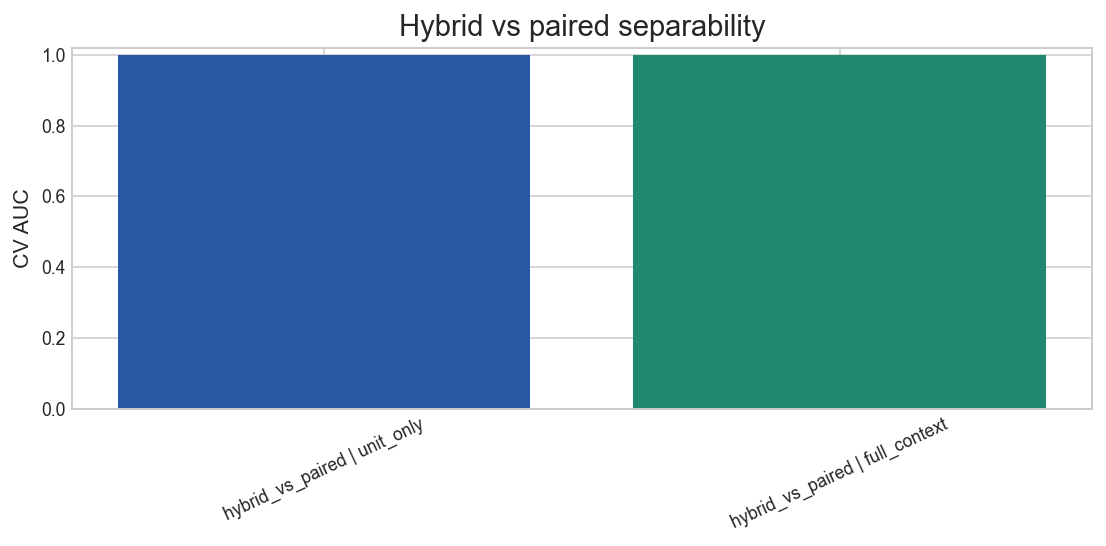

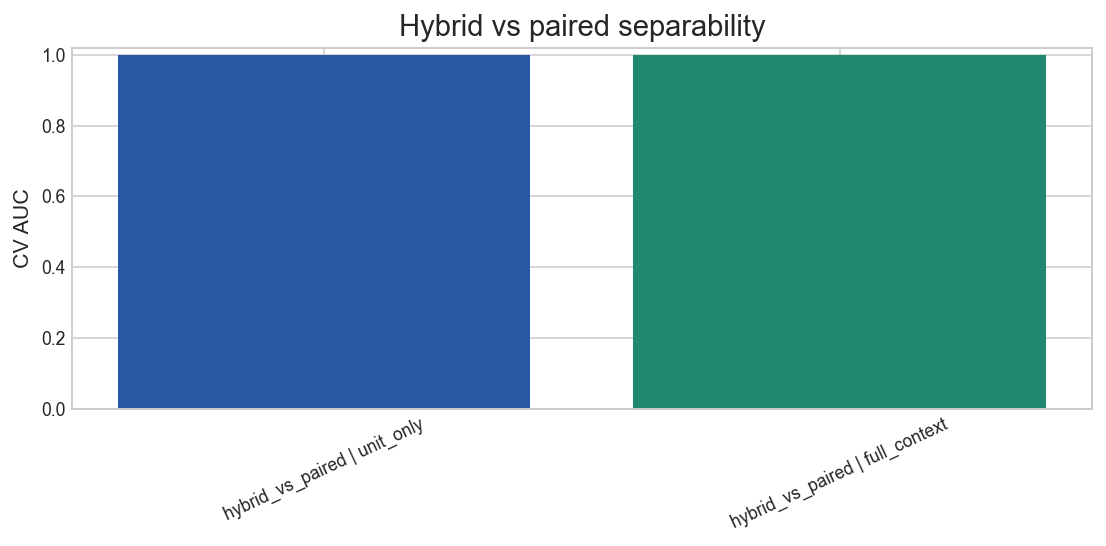

In [2]:
display(frozen_domain_summary)
save_table(frozen_domain_summary, table_dir, "domain_classifier_summary")
fig, _ = plot_domain_shift_separability(live_bundle.domain_summary)
save_figure(fig, fig_dir, "domain_separability")
fig


## 2. Which feature groups shift the most?

We want to know whether the shift lives only in broad recording context, or whether unit-level morphology is also shifted. The answer is: both matter, but context blocks and waveform-related features are especially strong.


,comparison,feature_set,feature_group,n_features,mean_abs_smd,median_abs_smd,max_abs_smd,mean_ks,mean_missing_gap
0,hybrid_vs_paired_all,context_only,recording_context,470,5.184643e-01,0.293348,5.305377e+00,0.400013,0.001440
1,hybrid_vs_paired_all,context_only,recording_relative,51,7.173363e-17,0.000000,3.855413e-16,0.014612,0.006651
2,hybrid_vs_paired_all,full_context,other,41,7.339956e-01,0.656970,2.565506e+00,0.533463,0.044855
3,hybrid_vs_paired_all,full_context,waveform_bins,30,7.107847e-01,0.471606,2.465191e+00,0.521906,0.000000
4,hybrid_vs_paired_all,full_context,amplitude,23,5.389827e-01,0.608839,1.401867e+00,0.581063,0.000347
5,hybrid_vs_paired_all,full_context,confusability,15,5.334700e-01,0.455961,1.091057e+00,0.296576,0.000178
6,hybrid_vs_paired_all,full_context,recording_context,470,5.184643e-01,0.293348,5.305377e+00,0.400013,0.001440
7,hybrid_vs_paired_all,full_context,spikeinterface,15,2.996418e-01,0.213002,9.615460e-01,0.306332,0.021903
8,hybrid_vs_paired_all,full_context,acg_bins,40,2.656075e-01,0.286654,5.105737e-01,0.265193,0.000000
9,hybrid_vs_paired_all,full_context,recording_relative,51,7.173363e-17,0.000000,3.855413e-16,0.014612,0.006651


,feature,paired_mean,hybrid_mean,abs_smd,feature_group
0,domain_label,1.000000,0.000000,2.251164,other
1,is_hybrid_labeled,0.000000,1.000000,2.251164,other
2,is_paired_unlabeled,0.976954,0.000000,2.215626,other
3,snr_recording_mean,4.359456,6.296528,2.136016,recording_context
4,wf_trough_to_peak_ms,0.987370,0.316027,1.902964,waveform
5,wf_zero_cross_post_ms,0.535986,0.171188,1.787951,waveform
6,wf_peak_trough_ms,0.954984,0.275069,1.742190,waveform
7,wf_bin_17,-0.400036,0.342792,1.713158,waveform
8,snr,4.359456,6.296528,1.701449,other
9,wf_ptp_ratio,4.359456,6.296528,1.701449,waveform


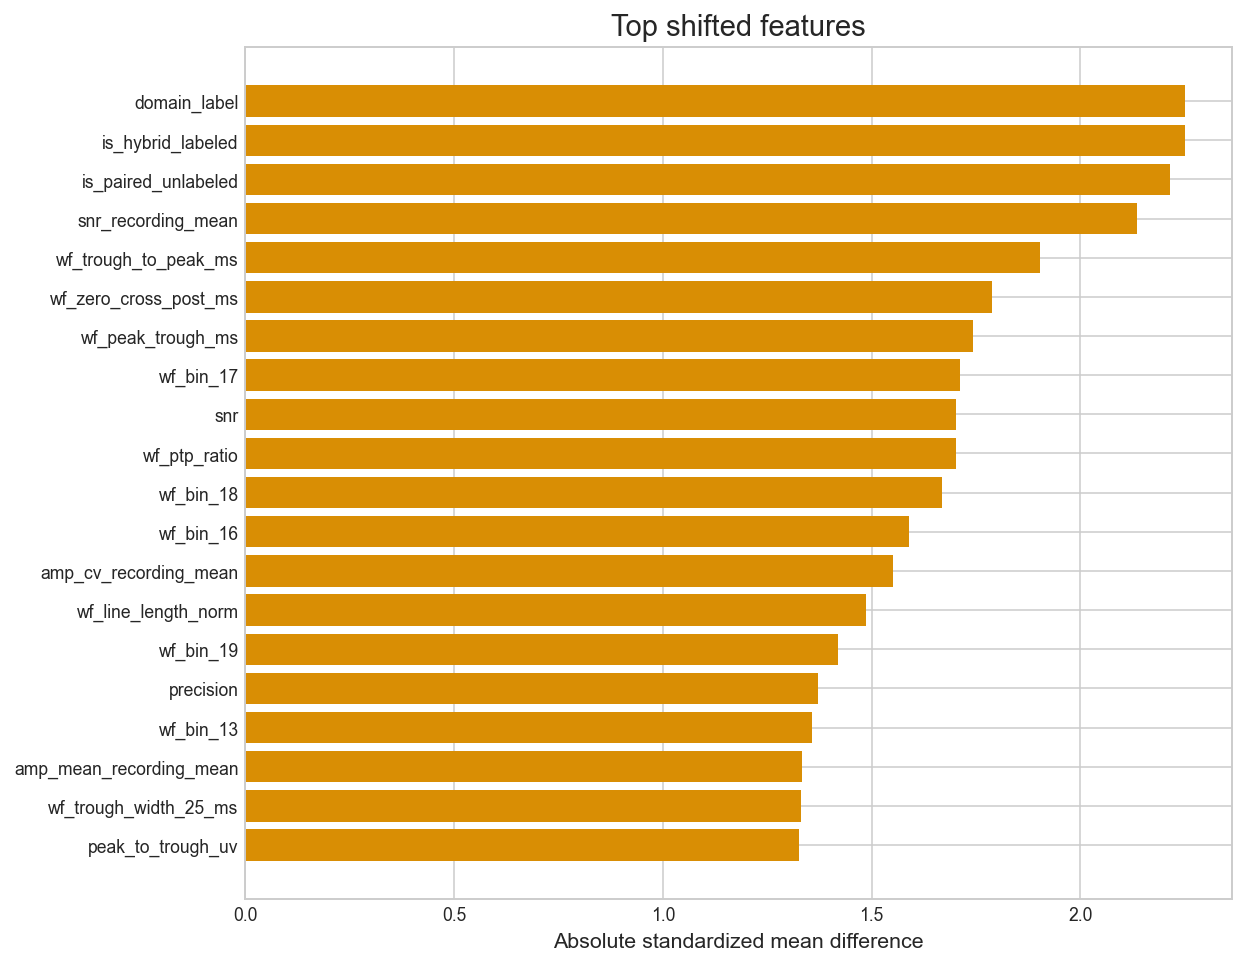

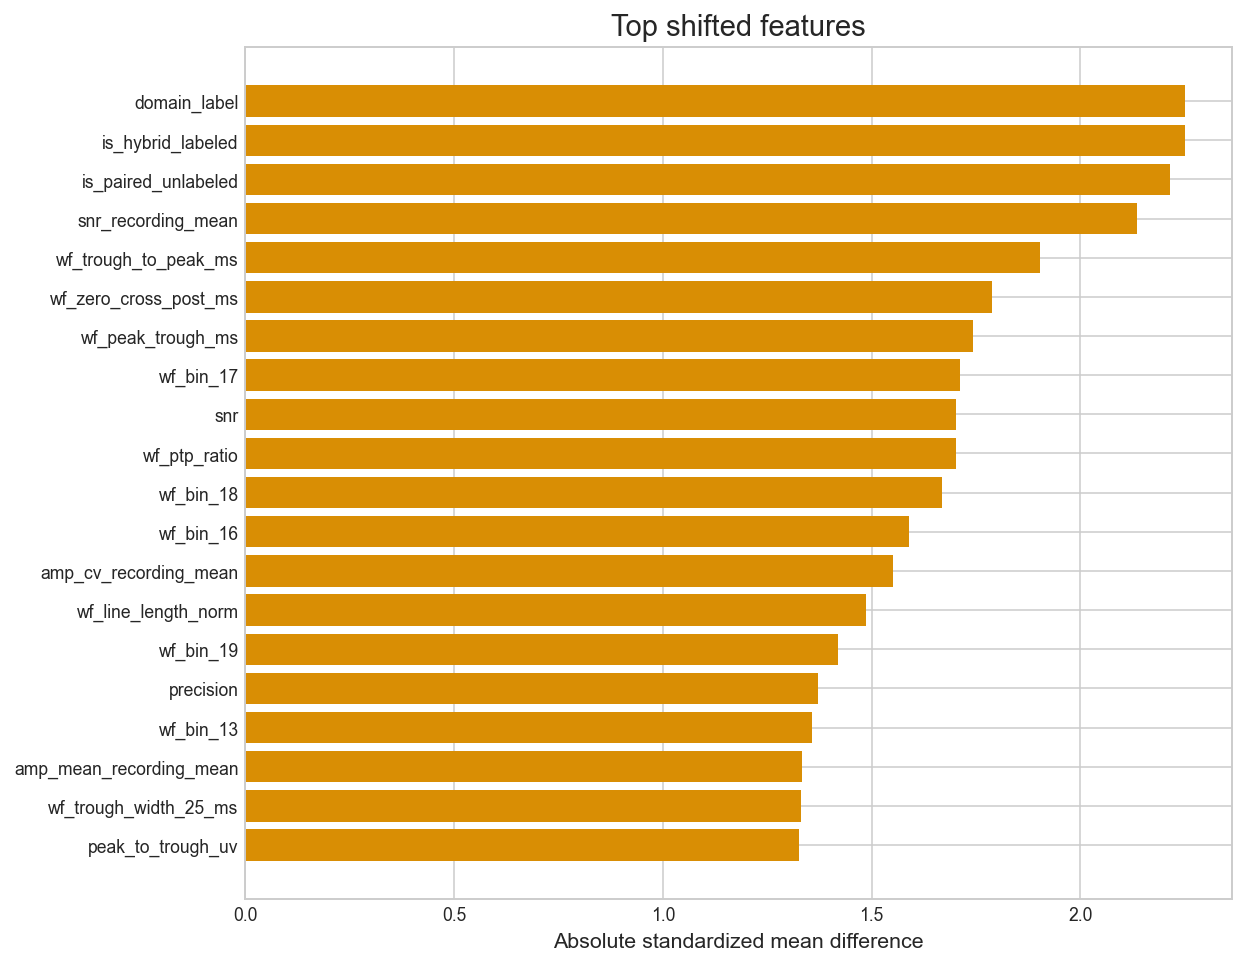

In [3]:
display(frozen_feature_group.head(12))
display(live_bundle.feature_shift.head(20))
save_table(frozen_feature_group, table_dir, "feature_group_shift_summary")
save_table(live_bundle.feature_shift.head(50), table_dir, "feature_shift_summary_top50")
fig, _ = plot_top_feature_shift(live_bundle.feature_shift, top_n=20)
save_figure(fig, fig_dir, "top_feature_shift")
fig


## 3. PCA structure

PCA does not prove transfer failure by itself, but it makes the geometry visible. Hybrid and paired units occupy different regions, and the paired families are not collapsed onto one compact manifold.


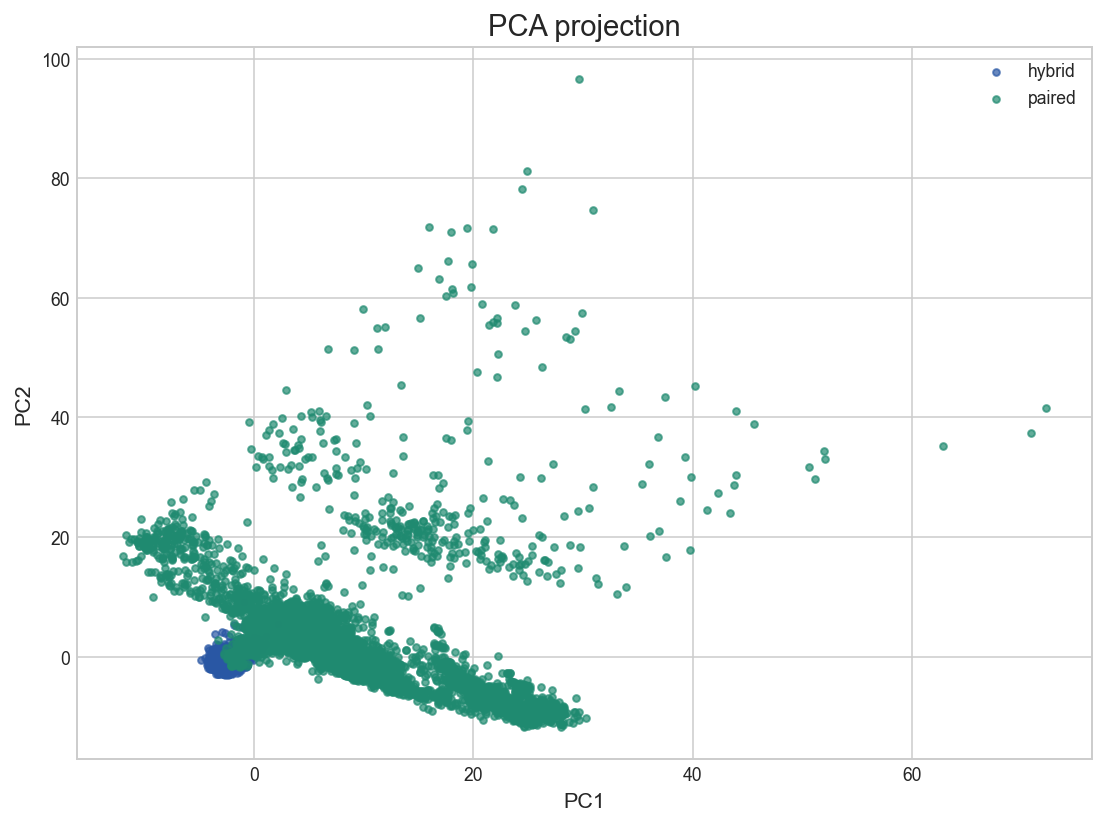

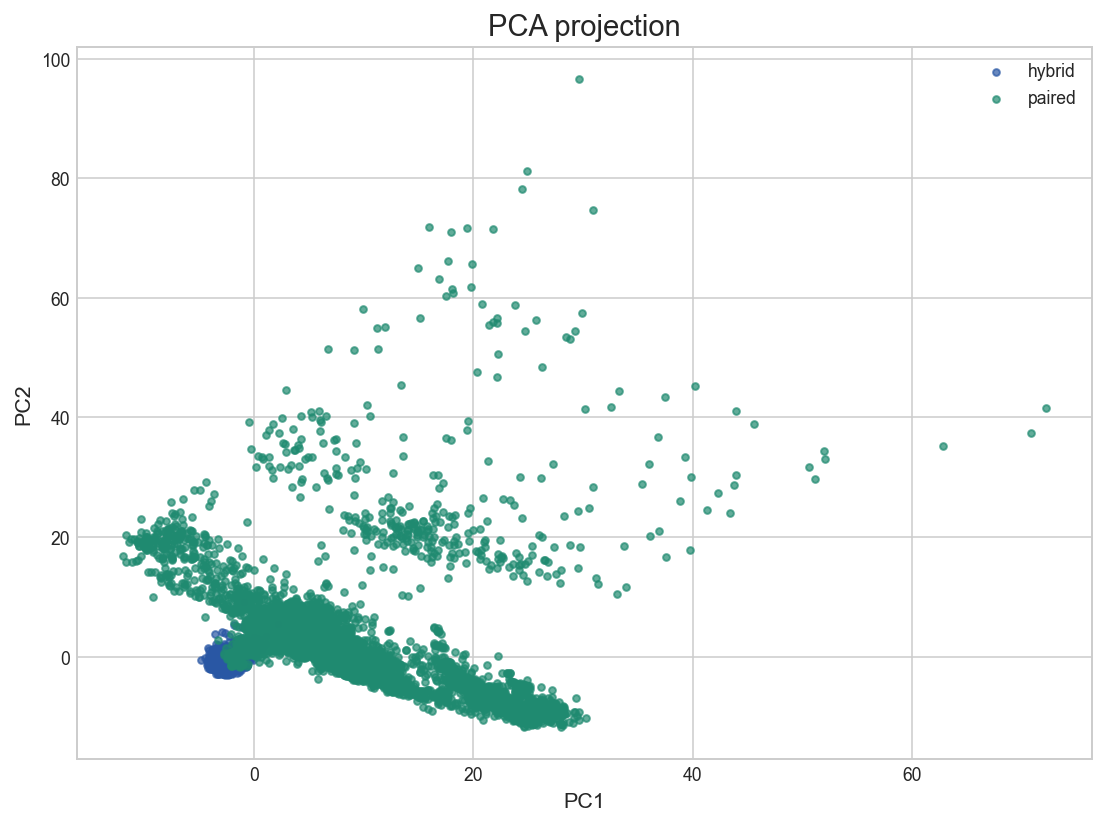

In [4]:
fig, _ = plot_pca_projection(live_bundle.pca_2d, color_col="dataset_type")
save_figure(fig, fig_dir, "pca_2d_by_domain")
fig


,study_set,pc1_mean,pc2_mean,n_rows,n_recordings
0,PAIRED_BOYDEN,9.530966,-1.848449,907,4
1,PAIRED_CRCNS_HC1,6.309200,4.674765,184,4
2,PAIRED_ENGLISH,5.546993,7.647507,3151,15
3,PAIRED_KAMPFF,17.530898,-5.177612,1743,4
4,PAIRED_MEA64C_YGER,1.463409,2.433810,2997,4


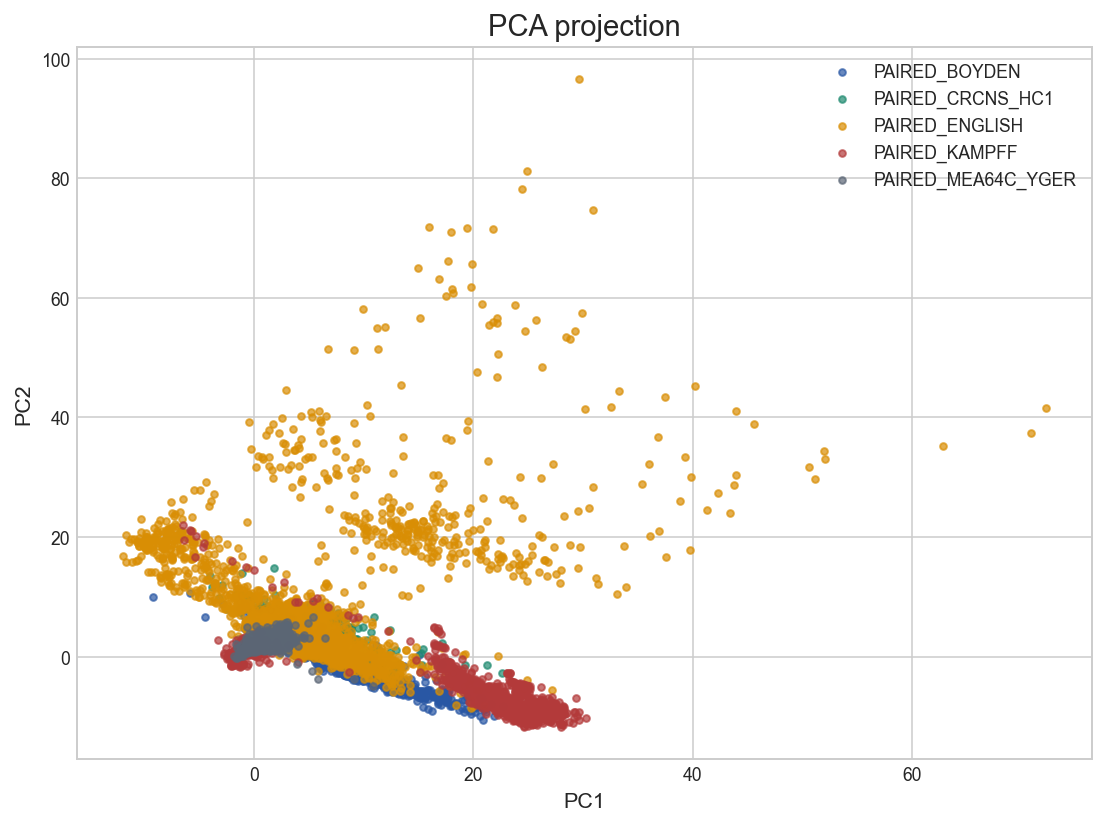

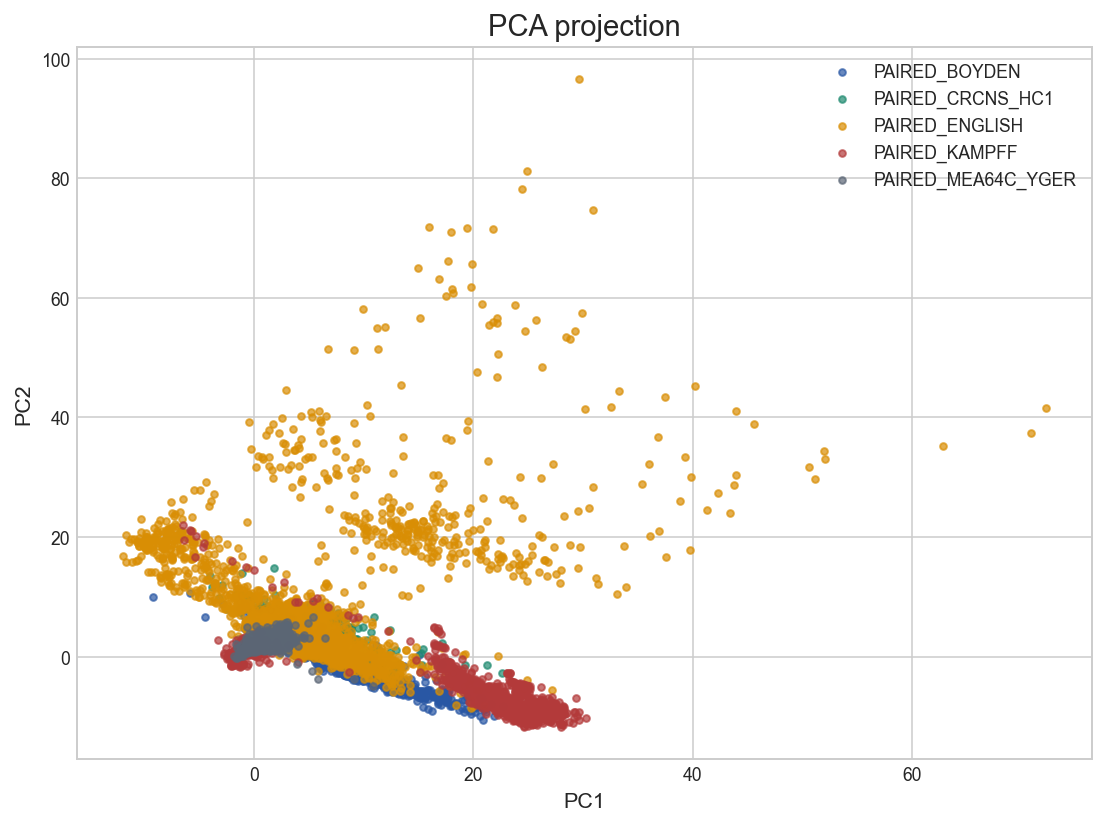

In [5]:
paired_only = live_bundle.pca_2d[live_bundle.pca_2d["dataset_type"] == "paired"].copy()
centroids = (
    paired_only.groupby("study_set", as_index=False)
    .agg(pc1_mean=("pc1", "mean"), pc2_mean=("pc2", "mean"), n_rows=("recording_key", "size"), n_recordings=("recording_key", "nunique"))
    .sort_values("study_set")
    .reset_index(drop=True)
)
display(centroids)
save_table(centroids, table_dir, "paired_family_pca_centroids")
fig, _ = plot_pca_projection(paired_only, color_col="study_set")
save_figure(fig, fig_dir, "pca_2d_paired_by_family")
fig


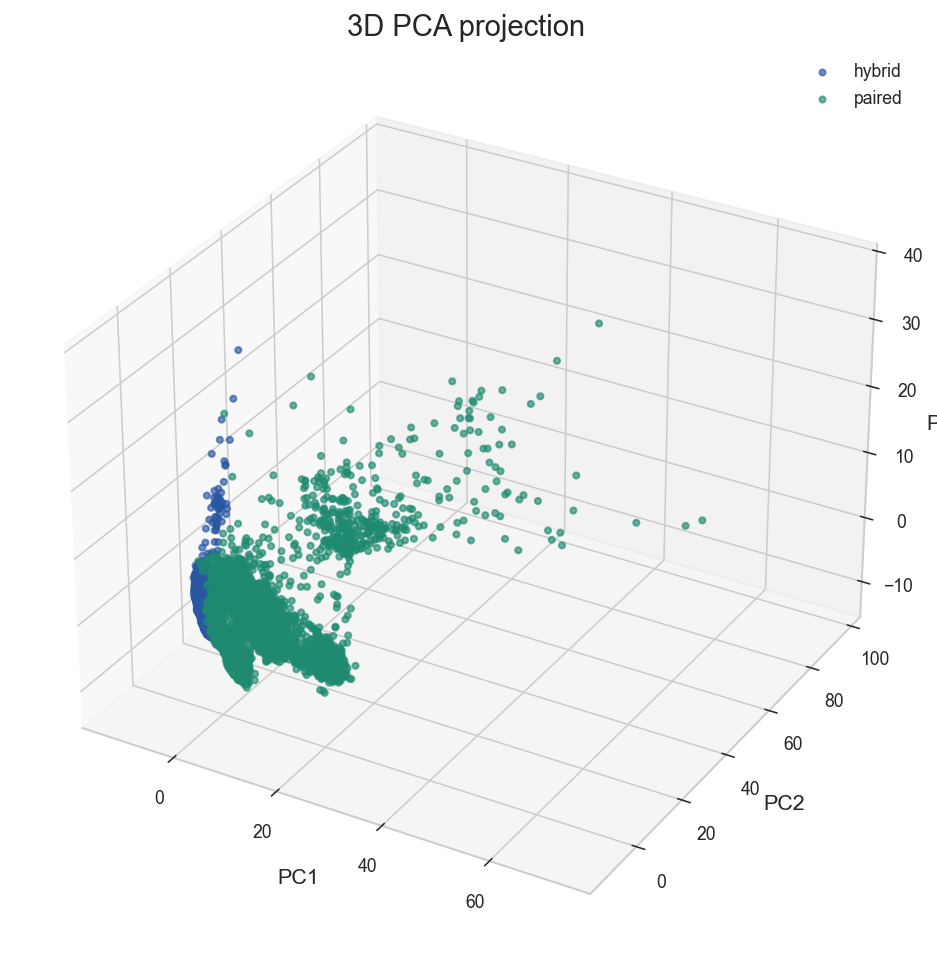

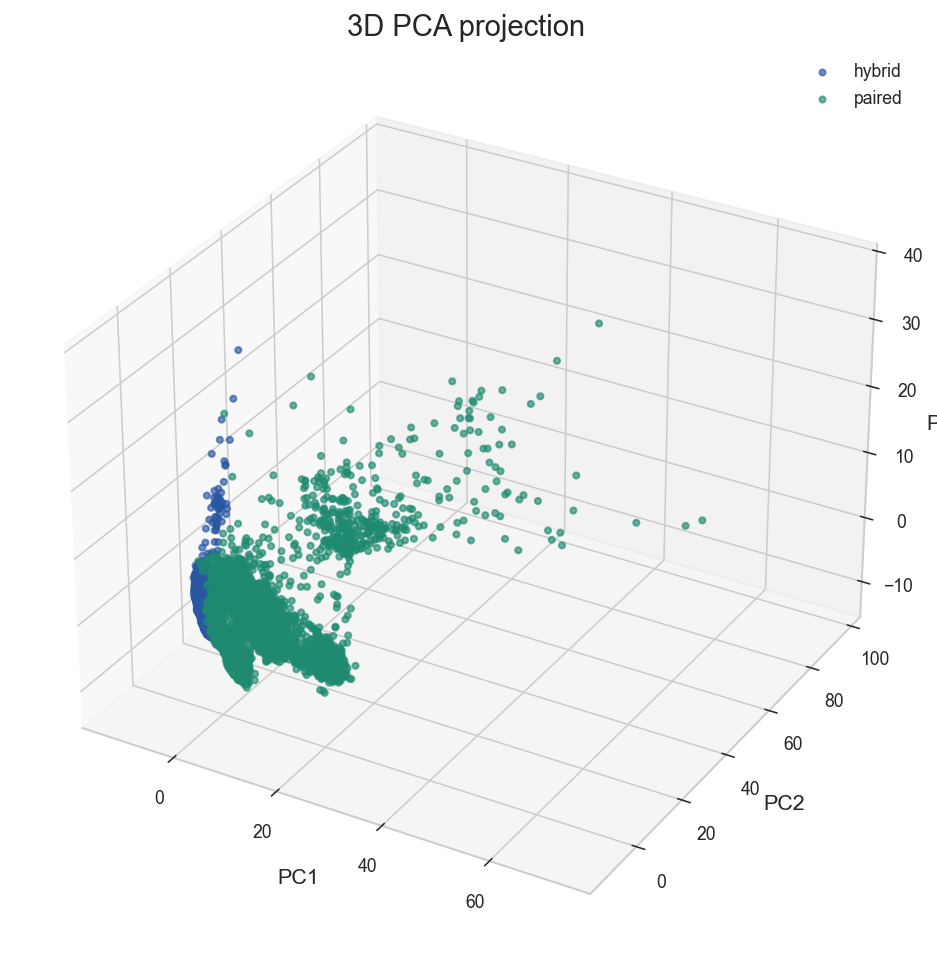

In [6]:
fig, _ = plot_pca_projection_3d(live_bundle.pca_3d, color_col="dataset_type")
save_figure(fig, fig_dir, "pca_3d_by_domain")
fig


In [7]:
unit_auc = float(frozen_domain_summary.query("feature_set == 'unit'").iloc[0]["cv_auc_mean"])
ctx_auc = float(frozen_domain_summary.query("feature_set == 'full_context'").iloc[0]["cv_auc_mean"])
top_group = frozen_feature_group.sort_values("mean_abs_smd", ascending=False).iloc[0]["feature_group"]
display(Markdown(
    f"""
## Key takeaways

- Hybrid vs paired separation is already very high on unit features (**AUC {unit_auc:.3f}**).
- With full context, the domain classifier becomes essentially perfect (**AUC {ctx_auc:.3f}**).
- The strongest shifted feature block in the frozen audit is **{top_group}**, which helps explain why context is both useful and potentially shortcut-prone.
- This notebook motivates the rest of the thesis: the task is not “train a stronger regressor”, it is “transfer under severe dataset shift”.
"""
))



## Key takeaways

- Hybrid vs paired separation is already very high on unit features (**AUC 0.976**).
- With full context, the domain classifier becomes essentially perfect (**AUC 1.000**).
- The strongest shifted feature block in the frozen audit is **other**, which helps explain why context is both useful and potentially shortcut-prone.
- This notebook motivates the rest of the thesis: the task is not “train a stronger regressor”, it is “transfer under severe dataset shift”.
